# Setup Environment & Workarounds
Menghindari masalah crash kernel pada Windows dengan OpenMP dan masalah kompatibilitas PyTorch.

In [1]:
import os
# Workaround for OpenMP library conflict (kernel crash)
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

# Workaround for PyTorch 2.5.1 and Transformers compatibility issue
import torch
if not hasattr(torch, 'float8_e8m0fnu'):
    setattr(torch, 'float8_e8m0fnu', None)

print("Environment setup completed.")


Environment setup completed.


# 1. Baca dan Eksplorasi Dataset
Dataset yang digunakan adalah Resume Dataset dari Kaggle.

Dataset berhasil dimuat!
Shape dataset: (2484, 4)

Informasi Kolom dan Missing Values:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2484 entries, 0 to 2483
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   ID           2484 non-null   int64 
 1   Resume_str   2484 non-null   object
 2   Resume_html  2484 non-null   object
 3   Category     2484 non-null   object
dtypes: int64(1), object(3)
memory usage: 77.8+ KB
None

Distribusi Category:


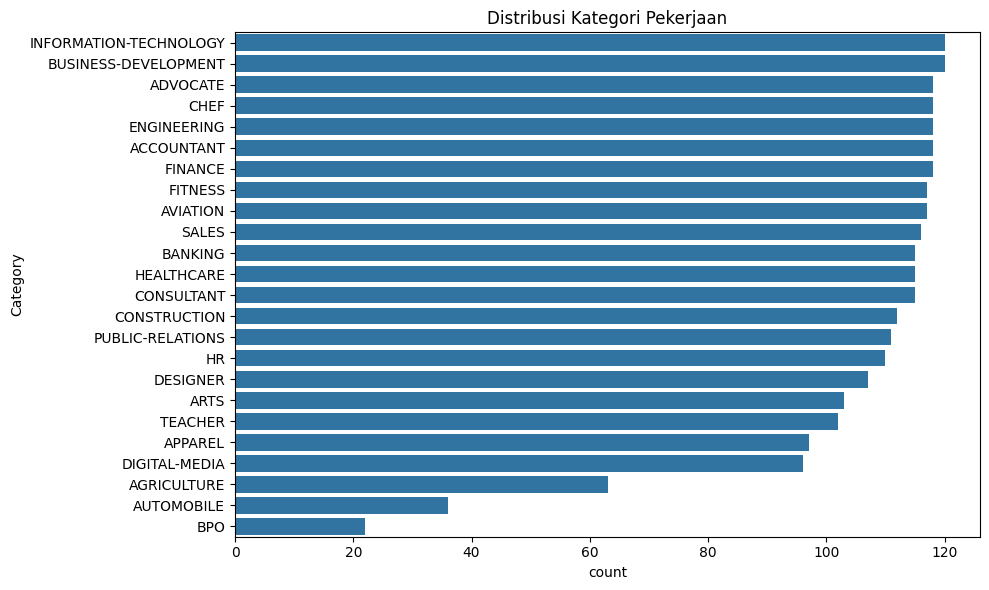


Contoh Isi Resume_str (1 baris):
         HR ADMINISTRATOR/MARKETING ASSOCIATE

HR ADMINISTRATOR       Summary     Dedicated Customer Service Manager with 15+ years of experience in Hospitality and Customer Service Management.   Respected builder and leader of customer-focused teams; strives to instill a shared, enthusiastic commitment to customer service.         Highlights         Focused on customer satisfaction  Team management  Marketing savvy  Conflict resolution techniques     Training and development  Skilled multi-task...

Statistik Panjang Teks:
Min   : 21
Max   : 38842
Mean  : 6295.31
Median: 5886.5


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Path ke dataset
dataset_path = 'unsupervised/Resume/Resume.csv'

try:
    df = pd.read_csv(dataset_path)
    print("Dataset berhasil dimuat!")
except FileNotFoundError:
    print(f"Error: Dataset tidak ditemukan di {dataset_path}. Pastikan file sudah tersedia.")
    df = pd.DataFrame() # Create empty dataframe to avoid hard crashes in subsequent cells if not found

if not df.empty:
    print(f"Shape dataset: {df.shape}")
    print("\nInformasi Kolom dan Missing Values:")
    print(df.info())
    
    print("\nDistribusi Category:")
    plt.figure(figsize=(10, 6))
    sns.countplot(y='Category', data=df, order=df['Category'].value_counts().index)
    plt.title('Distribusi Kategori Pekerjaan')
    plt.tight_layout()
    plt.show()
    
    print("\nContoh Isi Resume_str (1 baris):")
    print(df['Resume_str'].iloc[0][:500] + "...")
    
    # Statistik panjang teks
    df['text_length'] = df['Resume_str'].apply(lambda x: len(str(x)))
    print("\nStatistik Panjang Teks:")
    print(f"Min   : {df['text_length'].min()}")
    print(f"Max   : {df['text_length'].max()}")
    print(f"Mean  : {df['text_length'].mean():.2f}")
    print(f"Median: {df['text_length'].median()}")


# 2. Preprocessing Teks
Pembersihan teks: lowercase, hapus punctuation, angka, dan stopwords.

In [3]:
import re
import string
import nltk
from nltk.corpus import stopwords

# Download stopwords jika belum ada
nltk.download('stopwords', quiet=True)
stop_words = set(stopwords.words('english'))

def clean_text(text):
    if not isinstance(text, str):
        text = str(text)
    # Lowercase
    text = text.lower()
    # Hapus punctuation dan angka menggunakan regex
    text = re.sub(r'[^a-z\s]', ' ', text)
    # Tokenisasi sederhana berdasarkan spasi
    tokens = text.split()
    # Hapus stopwords
    tokens = [word for word in tokens if word not in stop_words and len(word) > 1]
    return ' '.join(tokens)

if not df.empty:
    print("Memulai preprocessing teks...")
    # Terapkan pembersihan
    df['cleaned_resume'] = df['Resume_str'].apply(clean_text)
    
    print("\nContoh Before / After Preprocessing:")
    print("--- BEFORE ---")
    print(df['Resume_str'].iloc[0][:300] + "...")
    print("\n--- AFTER ---")
    print(df['cleaned_resume'].iloc[0][:300] + "...")


Memulai preprocessing teks...

Contoh Before / After Preprocessing:
--- BEFORE ---
         HR ADMINISTRATOR/MARKETING ASSOCIATE

HR ADMINISTRATOR       Summary     Dedicated Customer Service Manager with 15+ years of experience in Hospitality and Customer Service Management.   Respected builder and leader of customer-focused teams; strives to instill a shared, enthusiastic commit...

--- AFTER ---
hr administrator marketing associate hr administrator summary dedicated customer service manager years experience hospitality customer service management respected builder leader customer focused teams strives instill shared enthusiastic commitment customer service highlights focused customer satisf...


# 3. Embedding dengan SBERT
Menggunakan `all-MiniLM-L6-v2` untuk mengonversi teks menjadi vektor embedding.

In [4]:
from sentence_transformers import SentenceTransformer
import time

model_name = 'all-MiniLM-L6-v2'
model = SentenceTransformer(model_name)

if not df.empty:
    print(f"Memulai proses embedding dengan {model_name}...")
    start_time = time.time()
    
    # Generate embeddings untuk seluruh resume
    # Proses ini mungkin memakan waktu beberapa menit tergantung CPU/GPU
    embeddings = model.encode(df['cleaned_resume'].tolist(), show_progress_bar=True)
    
    end_time = time.time()
    print(f"Embedding selesai dalam {end_time - start_time:.2f} detik.")
    print(f"Shape Embeddings: {embeddings.shape} (Harusnya n_samples x 384)")


d:\Hasil_Coding\NLP_Supervised\venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 7975.43it/s]


Memulai proses embedding dengan all-MiniLM-L6-v2...


Batches: 100%|██████████| 78/78 [00:06<00:00, 11.35it/s]

Embedding selesai dalam 6.88 detik.
Shape Embeddings: (2484, 384) (Harusnya n_samples x 384)


# 4. Clustering (KMeans & HDBSCAN)
Mengelompokkan resume berdasarkan kesamaan representasi semantik.

--- Menjalankan KMeans ---
KMeans Silhouette Score: 0.0701
KMeans Davies-Bouldin Index: 3.0976

--- Menjalankan HDBSCAN ---
HDBSCAN Silhouette Score (tanpa noise): 0.3316
HDBSCAN Davies-Bouldin Index (tanpa noise): 1.2850
Jumlah klaster HDBSCAN: 7
Persentase noise: 81.12%

--- Visualisasi Clustering dengan UMAP ---


d:\Hasil_Coding\NLP_Supervised\venv\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


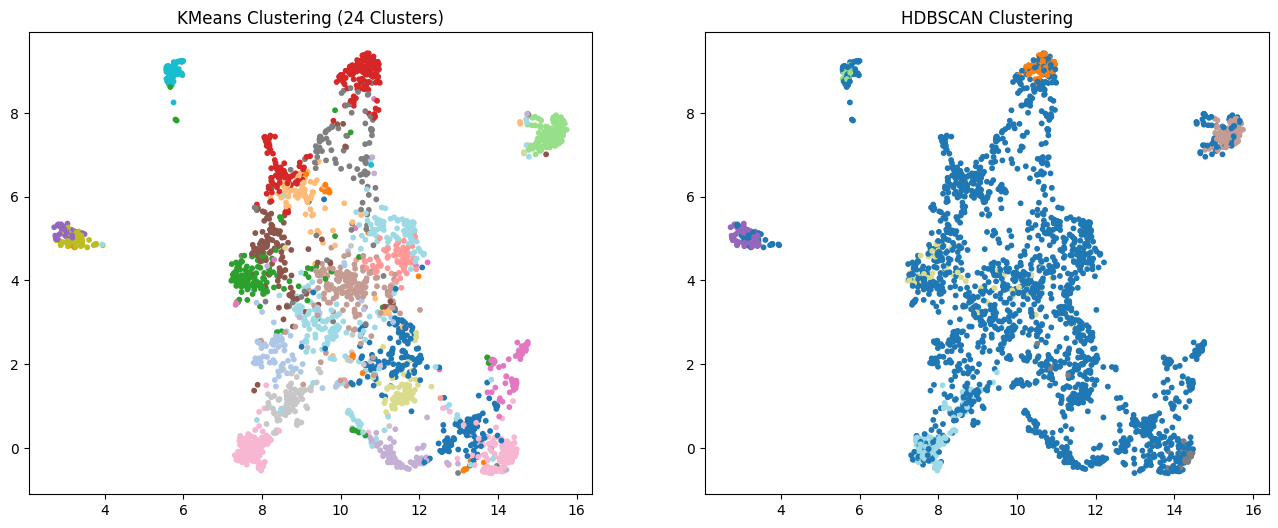

In [5]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
import hdbscan
import umap.umap_ as umap

if not df.empty and 'embeddings' in locals():
    # 4.1 KMeans Clustering
    print("--- Menjalankan KMeans ---")
    n_clusters = 24 # Karena ada 24 kategori pada dataset asli
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init='auto')
    kmeans_labels = kmeans.fit_predict(embeddings)
    df['kmeans_cluster'] = kmeans_labels
    
    sil_kmeans = silhouette_score(embeddings, kmeans_labels)
    db_kmeans = davies_bouldin_score(embeddings, kmeans_labels)
    print(f"KMeans Silhouette Score: {sil_kmeans:.4f}")
    print(f"KMeans Davies-Bouldin Index: {db_kmeans:.4f}")
    
    # 4.2 HDBSCAN Clustering
    print("\n--- Menjalankan HDBSCAN ---")
    # HDBSCAN bisa lambat pada dimensi 384, reduksi dimensi dengan UMAP sering disarankan sebelum HDBSCAN
    # Namun kita coba HDBSCAN langsung terlebih dahulu
    hdb = hdbscan.HDBSCAN(min_cluster_size=10, metric='euclidean')
    hdb_labels = hdb.fit_predict(embeddings)
    df['hdbscan_cluster'] = hdb_labels
    
    # Menghitung metrik untuk HDBSCAN (mengabaikan noise/label -1)
    mask = hdb_labels != -1
    if sum(mask) > 0 and len(set(hdb_labels[mask])) > 1:
        sil_hdb = silhouette_score(embeddings[mask], hdb_labels[mask])
        db_hdb = davies_bouldin_score(embeddings[mask], hdb_labels[mask])
        print(f"HDBSCAN Silhouette Score (tanpa noise): {sil_hdb:.4f}")
        print(f"HDBSCAN Davies-Bouldin Index (tanpa noise): {db_hdb:.4f}")
        print(f"Jumlah klaster HDBSCAN: {len(set(hdb_labels[mask]))}")
        print(f"Persentase noise: {sum(~mask)/len(mask)*100:.2f}%")
    else:
        print("HDBSCAN tidak menemukan klaster yang valid atau hanya menemukan 1 klaster.")
    
    # 4.3 Visualisasi dengan UMAP
    print("\n--- Visualisasi Clustering dengan UMAP ---")
    reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=42)
    embedding_2d = reducer.fit_transform(embeddings)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # Plot KMeans
    scatter1 = ax1.scatter(embedding_2d[:, 0], embedding_2d[:, 1], c=kmeans_labels, cmap='tab20', s=10)
    ax1.set_title('KMeans Clustering (24 Clusters)')
    
    # Plot HDBSCAN
    scatter2 = ax2.scatter(embedding_2d[:, 0], embedding_2d[:, 1], c=hdb_labels, cmap='tab20', s=10)
    ax2.set_title('HDBSCAN Clustering')
    
    plt.show()


# 5. Evaluasi Ground Truth
Menghitung NMI dan ARI antara hasil klaster dengan kategori sebenarnya.

In [6]:
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score
from sklearn.preprocessing import LabelEncoder

if not df.empty and 'kmeans_labels' in locals():
    # Encode label kategori asli
    le = LabelEncoder()
    true_labels = le.fit_transform(df['Category'])
    
    print("--- Evaluasi dengan Ground Truth (Original Category) ---")
    
    # Evaluasi KMeans
    nmi_kmeans = normalized_mutual_info_score(true_labels, kmeans_labels)
    ari_kmeans = adjusted_rand_score(true_labels, kmeans_labels)
    print(f"KMeans NMI: {nmi_kmeans:.4f}")
    print(f"KMeans ARI: {ari_kmeans:.4f}")
    
    # Evaluasi HDBSCAN
    nmi_hdb = normalized_mutual_info_score(true_labels, hdb_labels)
    ari_hdb = adjusted_rand_score(true_labels, hdb_labels)
    print(f"HDBSCAN NMI: {nmi_hdb:.4f}")
    print(f"HDBSCAN ARI: {ari_hdb:.4f}")


--- Evaluasi dengan Ground Truth (Original Category) ---
KMeans NMI: 0.5084
KMeans ARI: 0.3511
HDBSCAN NMI: 0.2440
HDBSCAN ARI: 0.0170


# 6. Simulasi Ranking Berdasarkan Similarity
Mencari resume yang mirip dengan satu resume query.

In [7]:
from sklearn.metrics.pairwise import cosine_similarity

def rank_similar(query_index, embeddings, top_n=10):
    query_vec = embeddings[query_index].reshape(1, -1)
    
    # Hitung cosine similarity dengan semua resume
    similarities = cosine_similarity(query_vec, embeddings)[0]
    
    # Dapatkan top_n indeks (mengabaikan indeks query itu sendiri)
    top_indices = np.argsort(similarities)[::-1][1:top_n+1]
    
    return top_indices, similarities[top_indices]

if not df.empty and 'embeddings' in locals():
    # Ambil index 0 sebagai query
    query_idx = 0
    query_category = df['Category'].iloc[query_idx]
    
    print(f"QUERY RESUME:")
    print(f"Kategori: {query_category}")
    print(f"Teks: {df['Resume_str'].iloc[query_idx][:200]}...\n")
    
    print("--- MENCARI 10 RESUME TERATAS YANG MIRIP ---")
    top_idx, top_scores = rank_similar(query_idx, embeddings, top_n=10)
    
    for i, (idx, score) in enumerate(zip(top_idx, top_scores), 1):
        cat = df['Category'].iloc[idx]
        print(f"{i}. [Score: {score:.4f}] Kategori: {cat} (Index: {idx})")


QUERY RESUME:
Kategori: HR
Teks:          HR ADMINISTRATOR/MARKETING ASSOCIATE

HR ADMINISTRATOR       Summary     Dedicated Customer Service Manager with 15+ years of experience in Hospitality and Customer Service Management.   Resp...

--- MENCARI 10 RESUME TERATAS YANG MIRIP ---
1. [Score: 0.8430] Kategori: HR (Index: 82)
2. [Score: 0.8385] Kategori: HR (Index: 38)
3. [Score: 0.8367] Kategori: HR (Index: 103)
4. [Score: 0.8365] Kategori: HR (Index: 1)
5. [Score: 0.8327] Kategori: ARTS (Index: 2330)
6. [Score: 0.8322] Kategori: HR (Index: 26)
7. [Score: 0.8299] Kategori: HR (Index: 46)
8. [Score: 0.8267] Kategori: HR (Index: 75)
9. [Score: 0.8241] Kategori: HR (Index: 33)
10. [Score: 0.8234] Kategori: HR (Index: 72)


# 7. Kesimpulan
Berdasarkan hasil analisis di atas:

1. **Kemampuan SBERT dalam merepresentasikan fitur CV tanpa label (Unsupervised)**: SBERT mampu menangkap pola bahasa secara umum. Nilai NMI dan ARI memberikan gambaran seberapa sejalan klaster yang dihasilkan dengan 24 kategori original.
2. **KMeans vs HDBSCAN**: KMeans memaksakan data masuk ke dalam jumlah *cluster* tetap (24). HDBSCAN lebih baik dalam mendeteksi struktur kepadatan data natural meskipun terkadang menghasilkan banyak *noise* atau klaster yang lebih sedikit. Kualitas sering kali terlihat dari nilai Silhouette atau DBI.
3. **Pencarian CV Relevan (Similarity)**: Tanpa adanya Job Description, mencari kandidat yang mirip dapat dilakukan dengan menggunakan salah satu kandidat referensi yang sukses (skor Cosine Similarity). Top 10 sering kali menghasilkan kandidat dengan kategori pekerjaan yang sama.
